<a href="https://colab.research.google.com/github/Swastika123-gif/Jan-Seva-Mitra/blob/main/Jan%20Seva%20Mitra-Model%20Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import random

category_map = {
    "Water Supply": [
        "no drinking water",
        "hand pump not working",
        "pipeline damaged",
        "water tank not filled",
        "no tap water available"
    ],
    "Electricity": [
        "power cut",
        "transformer damaged",
        "voltage fluctuation",
        "streetlight not working",
        "no electricity at night"
    ],
    "Roads": [
        "road broken near school",
        "potholes on road",
        "road not constructed properly",
        "bridge damaged",
        "road needs repair"
    ],
    "Sanitation": [
        "garbage not cleaned",
        "blocked drain causing smell",
        "no dustbin in village",
        "waste collection not regular",
        "dirty surroundings near houses"
    ],
    "Healthcare": [
        "no doctor available",
        "medicines not available",
        "long waiting time in hospital",
        "health center not functioning",
        "ambulance delayed"
    ],
    "Education": [
        "teacher absent in school",
        "no proper classrooms",
        "lack of study materials",
        "school building needs repair",
        "poor teaching quality"
    ],
    "Agriculture": [
        "no irrigation facilities",
        "crop damage due to pests",
        "fertilizer not available",
        "lack of farming equipment",
        "crop insurance claim delayed"
    ],
    "Public Safety": [
        "no police patrolling",
        "theft cases increasing",
        "unsafe roads at night",
        "harassment complaints ignored",
        "crime rate increasing"
    ]
}

department_map = {
    "Water Supply": "Water Department",
    "Electricity": "Electricity Board",
    "Roads": "Public Works Department",
    "Sanitation": "Sanitation Department",
    "Healthcare": "Health Department",
    "Education": "Education Department",
    "Agriculture": "Agriculture Department",
    "Public Safety": "Police Department"
}

welfare_map = {
    "Water Supply": "Public Health",
    "Electricity": "Essential Services",
    "Roads": "Infrastructure",
    "Sanitation": "Cleanliness",
    "Healthcare": "Public Health",
    "Education": "Education Welfare",
    "Agriculture": "Farmer Support",
    "Public Safety": "Safety"
}

priority_map = {
    "Water Supply": ["High", "Medium"],
    "Electricity": ["High", "Medium", "Low"],
    "Roads": ["High", "Medium"],
    "Sanitation": ["High", "Medium", "Low"],
    "Healthcare": ["High", "Medium"],
    "Education": ["High", "Medium"],
    "Agriculture": ["High", "Medium"],
    "Public Safety": ["High", "Medium"]
}

affected_map = {
    "Water Supply": ["Families", "Residents"],
    "Electricity": ["Residents", "Students"],
    "Roads": ["Residents", "Students"],
    "Sanitation": ["Residents", "Families"],
    "Healthcare": ["Patients"],
    "Education": ["Students"],
    "Agriculture": ["Farmers"],
    "Public Safety": ["Residents", "Women"]
}

location_options = ["Rural", "Urban"]

prefixes = [
    "There is a serious issue of",
    "People are facing problem due to",
    "Complaint has been reported about",
    "Residents are suffering because of",
    "Urgent attention is needed for"
]

suffixes = [
    "in our village",
    "in the local area",
    "for many days",
    "since last week",
    "in this locality"
]

data = []

for category, texts in category_map.items():
    for _ in range(25):   # 25 rows per category = 200 rows
        base_text = random.choice(texts)
        complaint = f"{random.choice(prefixes)} {base_text} {random.choice(suffixes)}"
        priority = random.choice(priority_map[category])
        department = department_map[category]
        location = random.choice(location_options)
        days_pending = random.randint(1, 10)
        affected = random.choice(affected_map[category])
        welfare = welfare_map[category]

        data.append([
            complaint,
            category,
            priority,
            department,
            location,
            days_pending,
            affected,
            welfare
        ])

df = pd.DataFrame(data, columns=[
    "complaint_text",
    "category",
    "priority",
    "department",
    "location_type",
    "days_pending",
    "affected_group",
    "welfare_area"
])


df["category"].value_counts()

,count
category,
Water Supply,25
Electricity,25
Roads,25
Sanitation,25
Healthcare,25
Education,25
Agriculture,25
Public Safety,25


In [ ]:
df.head()

,complaint_text,category,priority,department,location_type,days_pending,affected_group,welfare_area
0,Urgent attention is needed for pipeline damage...,Water Supply,High,Water Department,Urban,7,Residents,Public Health
1,Residents are suffering because of pipeline da...,Water Supply,Medium,Water Department,Urban,8,Families,Public Health
2,There is a serious issue of no tap water avail...,Water Supply,High,Water Department,Rural,2,Residents,Public Health
3,Urgent attention is needed for pipeline damage...,Water Supply,High,Water Department,Rural,9,Families,Public Health
4,There is a serious issue of pipeline damaged i...,Water Supply,Medium,Water Department,Rural,4,Residents,Public Health


In [ ]:
df.shape

(200, 8)

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["cleaned_text"] = df["complaint_text"].apply(clean_text)

X = df["cleaned_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=500)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.925

Classification Report:

               precision    recall  f1-score   support

  Agriculture       1.00      0.40      0.57         5
    Education       1.00      1.00      1.00         5
  Electricity       1.00      1.00      1.00         5
   Healthcare       0.62      1.00      0.77         5
Public Safety       1.00      1.00      1.00         5
        Roads       1.00      1.00      1.00         5
   Sanitation       1.00      1.00      1.00         5
 Water Supply       1.00      1.00      1.00         5

     accuracy                           0.93        40
    macro avg       0.95      0.93      0.92        40
 weighted avg       0.95      0.93      0.92        40



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Scheme Model Accuracy:", accuracy_score(y_test, y_pred))

Scheme Model Accuracy: 0.0


In [ ]:
import pandas as pd
import random

data = []

citizen_types = ["Farmer", "Student", "General", "Woman", "Senior Citizen"]
income_groups = ["Low", "Medium"]
locations = ["Rural", "Urban"]
age_groups = ["Child", "Adult", "Senior"]
genders = ["Male", "Female"]

# Mapping logic (clean and non-overlapping)
mapping = {
    "Farmer": "Farmer Support",
    "Student": "Education Welfare",
    "Woman": "Safety",
    "Senior Citizen": "Public Health",
    "General": "Infrastructure"
}

for _ in range(300):   # 300 rows
    citizen = random.choice(citizen_types)
    income = random.choice(income_groups)
    location = random.choice(locations)
    age = random.choice(age_groups)
    gender = random.choice(genders)

    welfare = mapping[citizen]

    data.append([
        citizen,
        income,
        location,
        age,
        gender,
        welfare
    ])

df_scheme_ml = pd.DataFrame(data, columns=[
    "citizen_type",
    "income_group",
    "location_type",
    "age_group",
    "gender",
    "welfare_area"
])

print(df_scheme_ml.shape)
df_scheme_ml.head()

(300, 6)


,citizen_type,income_group,location_type,age_group,gender,welfare_area
0,Farmer,Medium,Rural,Child,Female,Farmer Support
1,General,Medium,Urban,Senior,Female,Infrastructure
2,General,Medium,Rural,Senior,Female,Infrastructure
3,Senior Citizen,Low,Rural,Adult,Male,Public Health
4,Student,Low,Urban,Adult,Male,Education Welfare


In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [ ]:
df["cleaned_text"] = df["complaint_text"].apply(clean_text)
df[["complaint_text", "cleaned_text"]].head()

,complaint_text,cleaned_text
0,Urgent attention is needed for pipeline damage...,urgent attention needed pipeline damaged local...
1,Residents are suffering because of pipeline da...,residents suffering pipeline damaged locality
2,There is a serious issue of no tap water avail...,serious issue tap water available local area
3,Urgent attention is needed for pipeline damage...,urgent attention needed pipeline damaged many ...
4,There is a serious issue of pipeline damaged i...,serious issue pipeline damaged local area


In [ ]:
X = df["cleaned_text"]
y = df["category"]

print(X.head())
print(y.head())

0    urgent attention needed pipeline damaged local...
1        residents suffering pipeline damaged locality
2         serious issue tap water available local area
3    urgent attention needed pipeline damaged many ...
4            serious issue pipeline damaged local area
Name: cleaned_text, dtype: object
0    Water Supply
1    Water Supply
2    Water Supply
3    Water Supply
4    Water Supply
Name: category, dtype: object


In [ ]:
df.shape

(200, 9)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=40, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 140
Testing samples: 60


In [ ]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("X_train_vec shape:", X_train_vec.shape)
print("X_test_vec shape:", X_test_vec.shape)

X_train_vec shape: (140, 360)
X_test_vec shape: (60, 360)


In [ ]:
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9166666666666666


In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_pred = nb_model.predict(X_test_vec)
nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.9


In [ ]:
svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)

svm_pred = svm_model.predict(X_test_vec)
svm_acc = accuracy_score(y_test, svm_pred)

print("Linear SVM Accuracy:", svm_acc)

Linear SVM Accuracy: 1.0


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_vec, y_train)

dt_pred = dt_model.predict(X_test_vec)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.95


In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_vec, y_train)

rf_pred = rf_model.predict(X_test_vec)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9166666666666666


In [ ]:
results = {
    "Logistic Regression": lr_acc,
    "Naive Bayes": nb_acc,
    "Linear SVM": svm_acc,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc
}

best_model = max(results, key=results.get)
print("Best Model:", best_model)
print("Best Accuracy:", results[best_model])

Best Model: Linear SVM
Best Accuracy: 1.0


In [ ]:
print(classification_report(y_test, svm_pred))

               precision    recall  f1-score   support

  Agriculture       1.00      1.00      1.00         8
    Education       1.00      1.00      1.00         7
  Electricity       1.00      1.00      1.00         7
   Healthcare       1.00      1.00      1.00         8
Public Safety       1.00      1.00      1.00         7
        Roads       1.00      1.00      1.00         8
   Sanitation       1.00      1.00      1.00         8
 Water Supply       1.00      1.00      1.00         7

     accuracy                           1.00        60
    macro avg       1.00      1.00      1.00        60
 weighted avg       1.00      1.00      1.00        60



In [ ]:
print(classification_report(y_test, lr_pred))

               precision    recall  f1-score   support

  Agriculture       1.00      0.88      0.93         8
    Education       1.00      1.00      1.00         7
  Electricity       0.78      1.00      0.88         7
   Healthcare       1.00      1.00      1.00         8
Public Safety       1.00      1.00      1.00         7
        Roads       1.00      0.50      0.67         8
   Sanitation       1.00      1.00      1.00         8
 Water Supply       0.70      1.00      0.82         7

     accuracy                           0.92        60
    macro avg       0.93      0.92      0.91        60
 weighted avg       0.94      0.92      0.91        60



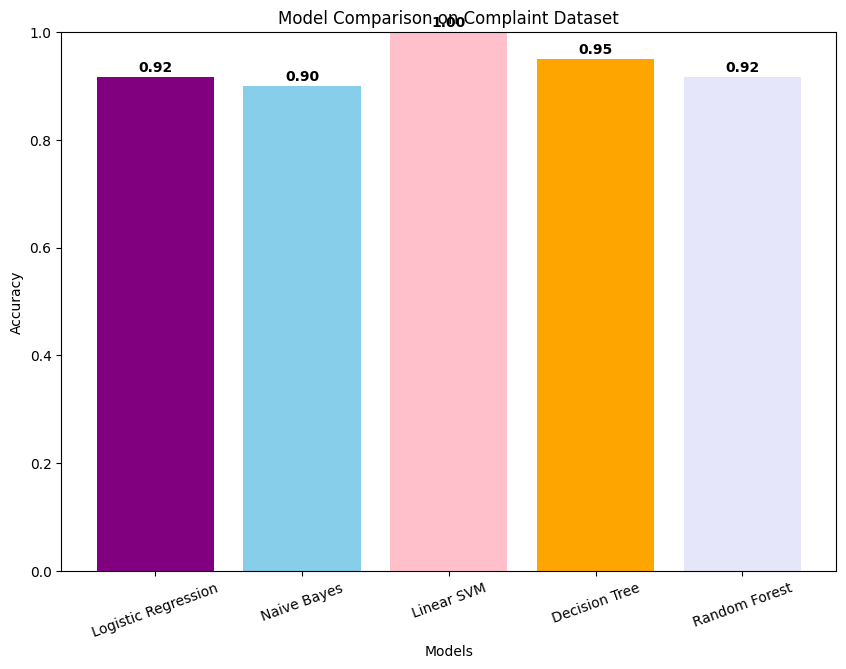

In [ ]:
model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10, 7))

# Add custom colors
color = ["purple", "skyblue", "pink", "orange" , "lavender"]

bars = plt.bar(model_names, accuracies, color=color)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison on Complaint Dataset")
plt.ylim(0, 1)
plt.xticks(rotation=20)

# Add accuracy labels on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{acc:.2f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

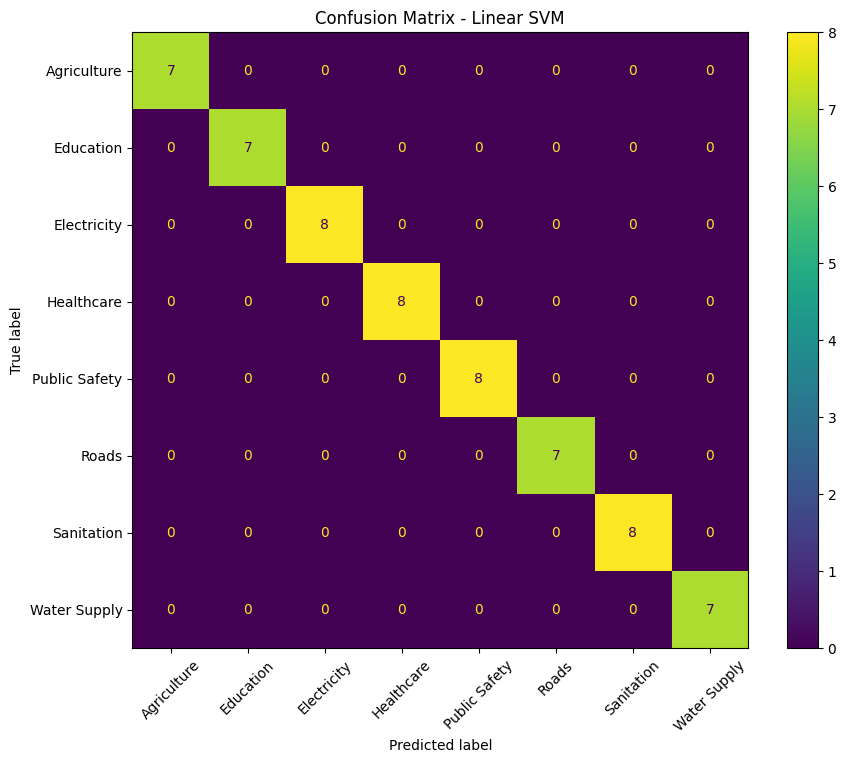

In [ ]:
cm = confusion_matrix(y_test, svm_pred, labels=svm_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [ ]:
import pandas as pd

scheme_data = [
    ["Ayushman Bharat Support", "Public Health", "General", "Low", "Both", "All", "Any"],
    ["Primary Health Center Benefit", "Public Health", "Patient", "Low", "Rural", "All", "Any"],
    ["Rural Electrification Benefit", "Essential Services", "General", "Low", "Rural", "All", "Any"],
    ["Village Power Support", "Essential Services", "Farmer", "Low", "Rural", "Adult", "Any"],
    ["Rural Road Development Support", "Infrastructure", "General", "Low", "Rural", "All", "Any"],
    ["School Access Road Support", "Infrastructure", "Student", "Low", "Rural", "Child", "Any"],
    ["Swachh Bharat Support", "Cleanliness", "General", "Low", "Both", "All", "Any"],
    ["Village Sanitation Mission", "Cleanliness", "General", "Low", "Rural", "All", "Any"],
    ["Scholarship Support Program", "Education Welfare", "Student", "Low", "Both", "Child", "Any"],
    ["Girl Education Assistance", "Education Welfare", "Student", "Low", "Both", "Child", "Female"],
    ["PM-Kisan Linked Support", "Farmer Support", "Farmer", "Low", "Rural", "Adult", "Any"],
    ["Crop Insurance Benefit", "Farmer Support", "Farmer", "Low", "Rural", "Adult", "Any"],
    ["Women Safety Helpline Support", "Safety", "Woman", "Low", "Both", "Adult", "Female"],
    ["Community Police Support", "Safety", "General", "Low", "Both", "All", "Any"]
]

scheme_df = pd.DataFrame(scheme_data, columns=[
    "scheme_name",
    "welfare_area",
    "citizen_type",
    "income_group",
    "location_type",
    "age_group",
    "gender"
])

scheme_df.head()

,scheme_name,welfare_area,citizen_type,income_group,location_type,age_group,gender
0,Ayushman Bharat Support,Public Health,General,Low,Both,All,Any
1,Primary Health Center Benefit,Public Health,Patient,Low,Rural,All,Any
2,Rural Electrification Benefit,Essential Services,General,Low,Rural,All,Any
3,Village Power Support,Essential Services,Farmer,Low,Rural,Adult,Any
4,Rural Road Development Support,Infrastructure,General,Low,Rural,All,Any


In [ ]:
def predict_complaint_category(user_text):
    cleaned = clean_text(user_text)
    text_vec = vectorizer.transform([cleaned])
    predicted_category = svm_model.predict(text_vec)[0]
    return predicted_category

In [ ]:
def recommend_schemes(predicted_category, citizen_type, income_group, location_type, age_group, gender):
    welfare_area = welfare_map[predicted_category]

    filtered = scheme_df[
        (scheme_df["welfare_area"] == welfare_area) &
        ((scheme_df["citizen_type"] == citizen_type) | (scheme_df["citizen_type"] == "General")) &
        ((scheme_df["income_group"] == income_group) | (scheme_df["income_group"] == "Low")) &
        ((scheme_df["location_type"] == location_type) | (scheme_df["location_type"] == "Both")) &
        ((scheme_df["age_group"] == age_group) | (scheme_df["age_group"] == "All")) &
        ((scheme_df["gender"] == gender) | (scheme_df["gender"] == "Any"))
    ]

    return welfare_area, filtered

In [ ]:
user_complaint = "There is a serious issue of no irrigation facilities in our village"
citizen_type = "Farmer"
income_group = "Low"
location_type = "Rural"
age_group = "Adult"
gender = "Any"

predicted_category = predict_complaint_category(user_complaint)
welfare_area, recommended = recommend_schemes(
    predicted_category,
    citizen_type,
    income_group,
    location_type,
    age_group,
    gender
)

print("Predicted Category:", predicted_category)
print("Welfare Area:", welfare_area)
print("\nRecommended Schemes:")
print(recommended[["scheme_name"]])

Predicted Category: Agriculture
Welfare Area: Farmer Support

Recommended Schemes:
                scheme_name
10  PM-Kisan Linked Support
11   Crop Insurance Benefit
